In [63]:
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense

from tensorflow.keras.datasets import mnist

In [64]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [65]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test , -1)

x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [66]:
model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation="relu", padding="same",name="conv_block_1_con2vd"),
    MaxPool2D(pool_size=(2, 2),name="conv_block_1_maxpool2d"),

    Conv2D(64, (3, 3), activation="relu",strides=(1,1), padding="same", name="conv_block_2_conv2d"),
    MaxPool2D(pool_size=(2, 2),name="conv_block_2_maxpool2d"),

    Flatten(),
    Dense(256, activation="relu", name="fc_1"),
    Dense(128, activation="relu", name="fc_2"),
    Dense(64, activation="relu", name="fc_3"),
    Dense(10, activation="softmax", name="output_fc_4"),
])


model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block_1_con2vd (Conv2D)    │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_1_maxpool2d          │ (None, 14, 14, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_2_conv2d (Conv2D)    │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_2_maxpool2d          │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_fc_4 (Dense)             │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 863,690 (3.29 MB)

 Trainable params: 863,690 (3.29 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [68]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10
)

history = history.history

history["accuracy"]
history["val_accuracy"]

history["loss"]
history["loss"]

Epoch 1/10


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(32,), output.shape=(32, 10)

In [14]:
# 28,28,1 => 3,3,32 ==> 28,28,32 ==> 14,14,32
# 14,14,32 => 3,3,32 ==> 14,14,32 ==> 7,7,32

In [60]:
model.evaluate(x_test, y_test)

ValueError: You must call `compile()` before using the model.

In [15]:
len(model.layers)

9

In [27]:
conv_1  = model.layers[0]
weights,bias = conv_1.weights
weights.shape

TensorShape([3, 3, 1, 32])

In [29]:
v_w = np.transpose(weights, (3,0,1,2))
v_w = np.squeeze(v_w)
v_w.shape

(32, 3, 3)

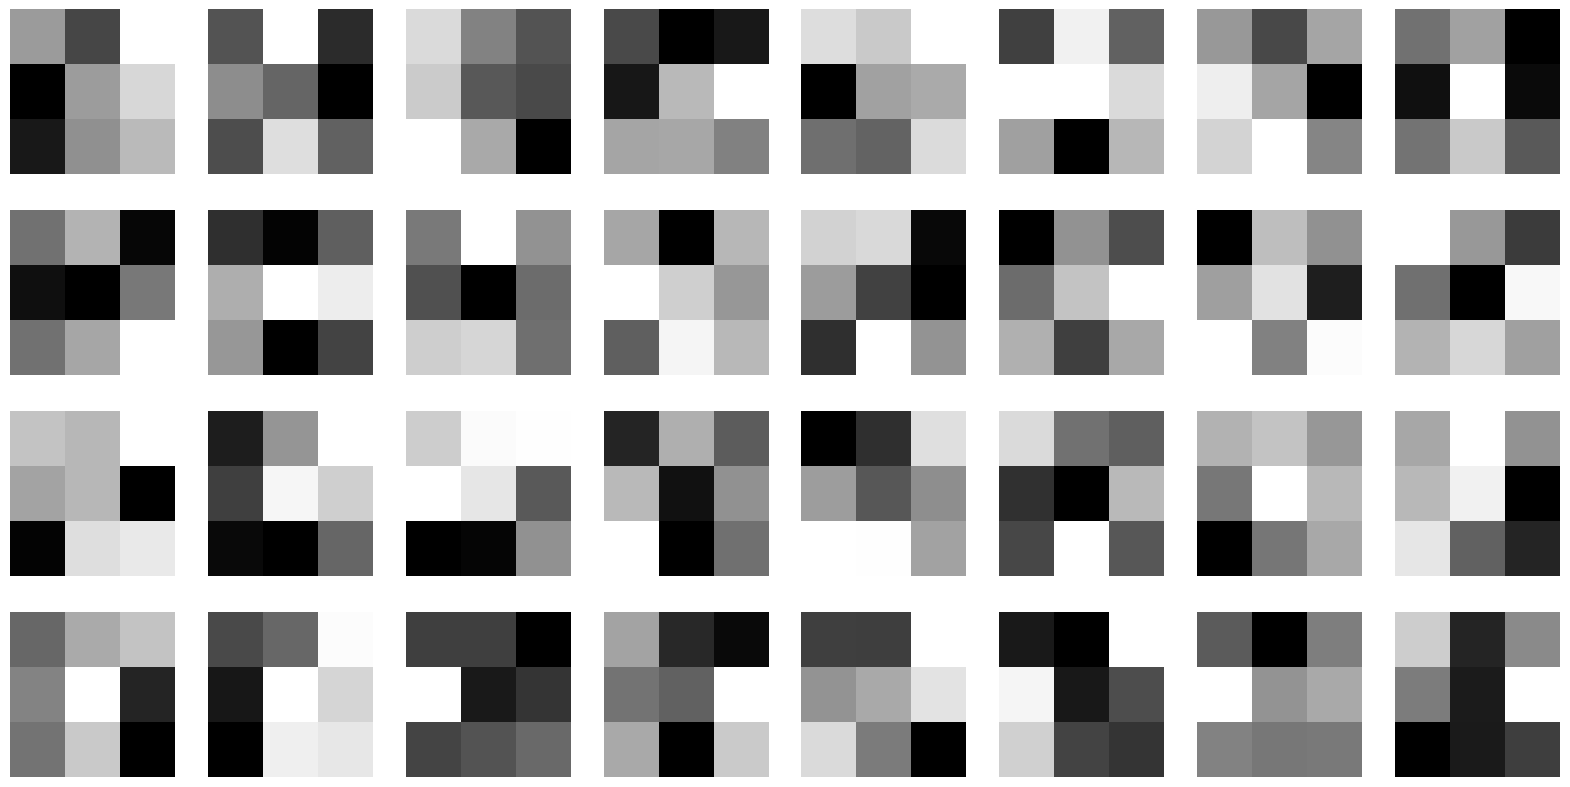

In [50]:
fig, axes = plt.subplots(4,8,figsize=(20,10))

for idx, ax in enumerate(axes.ravel()):
    ax.imshow(v_w[idx], cmap="gray")
    ax.set_axis_off()


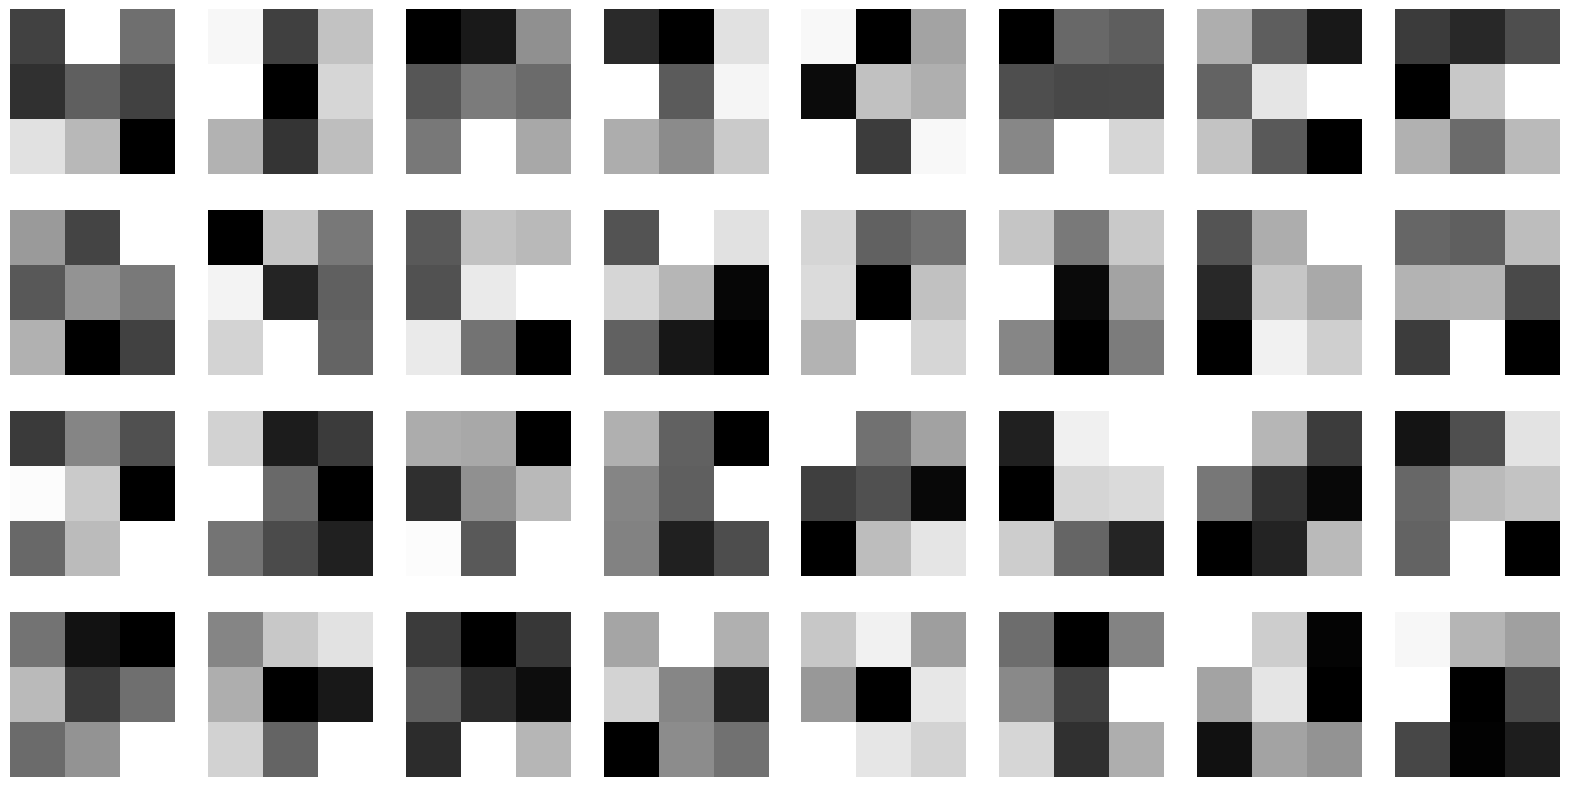

In [56]:
conv_2  = model.layers[2]
weights,bias = conv_2.weights

v_w = np.transpose(weights, (3,0,1,2))
v_w = np.squeeze(v_w)[:,:,:,0]

fig, axes = plt.subplots(4,8,figsize=(20,10))

for idx, ax in enumerate(axes.ravel()):
    ax.imshow(v_w[idx], cmap="gray")
    ax.set_axis_off()